<div class="report-header">
<table class="report-header-table">
<tr>
<td class="report-logo-ufop"><img src="template_assets/image1.jpeg" alt="UFOP"></td>
<td class="report-institution">
<strong>Universidade Federal de Ouro Preto</strong><br>
Instituto de Ciências Exatas e Aplicadas<br>
CDD105 — Estatística Descritiva e Visualização de Dados<br>
Professor: Alexandre Magno de Sousa
</td>
<td class="report-logo-icea"><img src="template_assets/image2.jpeg" alt="ICEA"></td>
</tr>
</table>
</div>

# Trabalho Prático

**Aluno:** Leonardo Isaac Silva Flores  
**Base de dados:** SF Bay Area Housing (`sfhousing.txt`)  
**Recorte analisado:** vendas registradas em 2005


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

plt.style.use('classic')
pd.set_option('display.float_format', '{:.2f}'.format)

## 1. Seleção da amostra

O enunciado orienta a escolha de um único ano anterior a 2006. Foi selecionado **2005**, o ano mais recente que atende a essa condição. A escolha permite trabalhar com um período próximo ao início da alta de preços mencionada no enunciado, sem afirmar que o mercado já estivesse estável.

O recorte é feito em uma cópia do conjunto original, que permanece inalterado.

## 2. Registro da análise em Notebook Jupyter

Conforme o segundo item do checklist da disciplina, esta análise é mantida em um **Notebook Jupyter** reproduzível. Nele ficam registrados o carregamento do arquivo `sfhousing.txt`, a conversão da coluna `date`, a seleção das vendas de 2005, os tratamentos adotados, os cálculos, os gráficos e as interpretações. A saída a seguir confere o tamanho da base completa, o tamanho e a proporção da amostra e suas cinco primeiras observações.


In [2]:
df_orig = pd.read_csv('sfhousing.txt', sep=',')
df_orig['date'] = pd.to_datetime(df_orig['date'], errors='coerce')

# Cópia contendo somente as vendas registradas em 2005
df = df_orig[df_orig['date'].dt.year == 2005].copy().reset_index(drop=True)

print(f'Dataset completo : {df_orig.shape[0]:,} registros')
print(f'Amostra de 2005  : {df.shape[0]:,} registros ({df.shape[0]/df_orig.shape[0]*100:.1f}% do total)')
df.head(5)

Dataset completo : 521,493 registros
Amostra de 2005  : 113,991 registros (21.9% do total)


,county,city,zip,street,price,br,lsqft,bsqft,year,date,datesold
0,Alameda County,Alameda,94501.00,1001 Santa Clara Avenue,880000.00,7.00,5914.00,3866.00,1995.00,2005-11-06,NaN
1,Alameda County,Alameda,94501.00,1001 Shoreline Drive \#201,570000.00,2.00,39353.00,1360.00,1970.00,2005-07-31,NaN
2,Alameda County,Alameda,94501.00,1001 Shoreline Drive \#204,525000.00,2.00,39353.00,1360.00,1970.00,2005-04-17,NaN
3,Alameda County,Alameda,94501.00,1001 Shoreline Drive \#208,535000.00,2.00,39353.00,1360.00,1970.00,2005-07-17,NaN
4,Alameda County,Alameda,94501.00,1001 Shoreline Drive \#307,515000.00,2.00,39353.00,1360.00,1970.00,2005-02-13,NaN


## 3. Atributos e suas Características

### 3a-b. Nomes, tipos e natureza das variáveis


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113991 entries, 0 to 113990
Data columns (total 11 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   county    113991 non-null  str           
 1   city      113991 non-null  str           
 2   zip       113983 non-null  float64       
 3   street    113991 non-null  str           
 4   price     113991 non-null  float64       
 5   br        91921 non-null   float64       
 6   lsqft     94160 non-null   float64       
 7   bsqft     96971 non-null   float64       
 8   year      93863 non-null   float64       
 9   date      113991 non-null  datetime64[us]
 10  datesold  0 non-null       str           
dtypes: datetime64[us](1), float64(6), str(4)
memory usage: 9.6 MB


In [4]:
tipo_map = {
    'county'  : ('Categórico', 'Nominal', 'Condado'),
    'city'    : ('Categórico', 'Nominal', 'Cidade'),
    'zip'     : ('Categórico', 'Nominal', 'Identificador postal'),
    'street'  : ('Texto', 'Nominal', 'Endereço'),
    'price'   : ('Numérico (float)', 'Quantitativo contínuo', 'Dólares'),
    'br'      : ('Numérico (float)', 'Quantitativo discreto', 'Contagem'),
    'lsqft'   : ('Numérico (float)', 'Quantitativo contínuo', 'Pés quadrados'),
    'bsqft'   : ('Numérico (float)', 'Quantitativo contínuo', 'Pés quadrados'),
    'year'    : ('Numérico (float)', 'Quantitativo discreto', 'Ano'),
    'date'    : ('Data', 'Temporal', 'Data da venda'),
    'datesold': ('Data', 'Temporal', 'Segunda data de venda'),
}
pd.DataFrame(tipo_map, index=['Tipo no arquivo', 'Natureza', 'Observação']).T

,Tipo no arquivo,Natureza,Observação
county,Categórico,Nominal,Condado
city,Categórico,Nominal,Cidade
zip,Categórico,Nominal,Identificador postal
street,Texto,Nominal,Endereço
price,Numérico (float),Quantitativo contínuo,Dólares
br,Numérico (float),Quantitativo discreto,Contagem
lsqft,Numérico (float),Quantitativo contínuo,Pés quadrados
bsqft,Numérico (float),Quantitativo contínuo,Pés quadrados
year,Numérico (float),Quantitativo discreto,Ano
date,Data,Temporal,Data da venda


### 3c. Valores ausentes


In [5]:
missing = pd.DataFrame({
    'ausentes': df.isna().sum(),
    '% ausentes': (df.isna().mean() * 100).round(2)
})
missing[missing['ausentes'] > 0]

,ausentes,% ausentes
zip,8,0.01
br,22070,19.36
lsqft,19831,17.40
bsqft,17020,14.93
year,20128,17.66
datesold,113991,100.00


**Tratamento dos valores ausentes**

- `datesold` não contém valores no recorte de 2005 e, por isso, não participa das análises.
- `br`, `lsqft`, `bsqft` e `year` apresentam, respectivamente, cerca de 19,36%, 17,40%, 14,93% e 17,66% de ausência. Em cada cálculo ou gráfico são usadas apenas as observações disponíveis para as variáveis envolvidas (`dropna`), sem eliminar linhas das demais análises.
- `zip` possui oito valores ausentes na amostra original. Esses registros são desconsiderados somente na análise geográfica.

Não foi feita imputação, pois ela alteraria artificialmente as distribuições que se pretende descrever. Essa decisão reduz o número de observações em algumas análises e deve ser considerada na interpretação dos resultados.

### 3d. Ruído nos dados


In [6]:
num_cols = ['price', 'br', 'lsqft', 'bsqft', 'year']
key_cols = ['city', 'zip', 'street', 'date']

duplicadas = df.duplicated(key_cols, keep=False)
print('Duplicidades segundo a chave informada no enunciado:',
      duplicadas.sum(), 'linhas envolvidas')
display(df.loc[duplicadas].sort_values(key_cols))

print()
print('Valores extremos antes da limpeza:')
print(df[num_cols].agg(['min', 'max']).to_string())

# Limites operacionais usados para separar registros incompatíveis ou muito
# distantes do padrão residencial. Eles não definem outliers estatísticos.
regras = {
    'ano fora de 1800–2005': df['year'].notna() & ~df['year'].between(1800, 2005),
    'terreno acima de 500.000 pés²': df['lsqft'].notna() & df['lsqft'].gt(500_000),
    'área construída acima de 20.000 pés²': df['bsqft'].notna() & df['bsqft'].gt(20_000),
    'mais de 20 quartos': df['br'].notna() & df['br'].gt(20),
}
for nome, mascara in regras.items():
    print(f'{nome}: {mascara.sum():,} registro(s)')

mascara_ruido = np.logical_or.reduce(list(regras.values()))
n_antes = len(df)
df = df.loc[~mascara_ruido].copy().reset_index(drop=True)

print()
print(f'Registros separados pelos critérios: {n_antes - len(df):,} ({(n_antes-len(df))/n_antes*100:.2f}%)')
print(f'Registros mantidos na análise      : {len(df):,}')

Duplicidades segundo a chave informada no enunciado: 4 linhas envolvidas


,county,city,zip,street,price,br,lsqft,bsqft,year,date,datesold
61919,San Mateo County,Daly City,94015.00,370 Imperial Way,271000.00,NaN,NaN,483.00,1974.00,2005-10-16,NaN
61920,San Mateo County,Daly City,94015.00,370 Imperial Way,275000.00,NaN,NaN,483.00,1974.00,2005-10-16,NaN
82449,Santa Clara County,Morgan Hill,95037.00,585 Calle Buena Vista,594000.00,NaN,153767.00,NaN,NaN,2005-03-20,NaN
82452,Santa Clara County,Morgan Hill,95037.00,585 Calle Buena Vista,659000.00,NaN,153767.00,NaN,NaN,2005-03-20,NaN



Valores extremos antes da limpeza:
          price    br        lsqft      bsqft    year
min    48000.00  1.00        19.00     122.00 1904.00
max 10000000.00 52.00 392040000.00 1856544.00 3860.00
ano fora de 1800–2005: 2 registro(s)
terreno acima de 500.000 pés²: 233 registro(s)
área construída acima de 20.000 pés²: 7 registro(s)
mais de 20 quartos: 5 registro(s)

Registros separados pelos critérios: 246 (0.22%)
Registros mantidos na análise      : 113,745


Os extremos incluem dois anos de construção posteriores a 2005, 233 terrenos acima de 500 mil pés², sete áreas construídas acima de 20 mil pés² e cinco registros com mais de 20 quartos. Esses critérios separaram 246 linhas (0,22%) para evitar que possíveis erros de escala ou de registro dominassem os gráficos e as medidas.

Os limites de área e de quartos são regras operacionais, não provas de erro. Portanto, os registros originais foram preservados em `df_orig`, e uma análise voltada especificamente a propriedades rurais ou de luxo deveria reavaliá-los. As duas duplicidades encontradas segundo a chave indicada no enunciado também foram apenas apresentadas, pois as linhas não são cópias completas e podem representar correções ou registros distintos.

## 4. Variável-alvo

O problema proposto é de **regressão**, pois se pretende estimar um valor numérico.

- **Variável dependente:** `price`.
- **Possíveis variáveis explicativas:** `br`, `lsqft`, `bsqft`, `year`, `city`, `county` e componentes temporais derivados de `date`.

`street` e `zip` são identificadores de localização e exigem codificação apropriada antes de entrar em um modelo. `datesold` não pode ser usada no recorte porque está vazia. A escolha definitiva das variáveis pertence à etapa de modelagem; aqui elas são apenas examinadas de forma exploratória.

## 5. Sumarização Estatística

A tabela abaixo reúne as principais medidas de tendência central, dispersão e forma para as variáveis numéricas.


In [7]:
dt = df[num_cols].describe()
dt.loc['variance'] = df[num_cols].var()
dt.loc['cv'] = dt.loc['std'] / dt.loc['mean']
dt.loc['range'] = df[num_cols].max() - df[num_cols].min()
dt.loc['siqr'] = (dt.loc['75%'] - dt.loc['25%']) / 2
dt.loc['skewness'] = df[num_cols].skew()
dt.loc['kurtosis'] = df[num_cols].kurt()

ordem = ['count', 'mean', '50%', 'std', 'variance', 'cv', 'min', '25%',
         '75%', 'max', 'range', 'siqr', 'skewness', 'kurtosis']
dt.loc[ordem].T.round(2)

,count,mean,50%,std,variance,cv,min,25%,75%,max,range,siqr,skewness,kurtosis
price,113745.00,679612.33,605000.00,372842.39,139011446559.50,0.55,48000.00,461000.00,779000.00,10000000.00,9952000.00,159000.00,3.85,34.03
br,91731.00,3.02,3.00,0.99,0.97,0.33,1.00,2.00,4.00,20.00,19.00,1.00,0.76,4.76
lsqft,93919.00,9609.33,5663.00,25965.12,674187277.27,2.70,19.00,3750.00,7700.00,499633.00,499614.00,1975.00,10.54,137.41
bsqft,96769.00,1595.46,1426.00,711.88,506771.28,0.45,122.00,1112.00,1894.00,12222.00,12100.00,391.00,1.85,6.64
year,93666.00,1966.07,1970.00,23.76,564.40,0.01,1904.00,1952.00,1985.00,2003.00,99.00,16.50,-0.67,-0.08


- Em `price`, a média (aproximadamente US$ 680 mil) é superior à mediana (US$ 605 mil), em concordância com a assimetria positiva. O CV de 0,55 indica dispersão considerável em relação à média.
- `lsqft` apresenta a maior dispersão relativa (CV de 2,70) e forte assimetria à direita. A curtose elevada indica caudas mais pesadas que as da distribuição normal e reforça a inspeção dos extremos.
- `br` é mais concentrada (CV de 0,33), com mediana de três quartos.
- `year` tem assimetria negativa (-0,67). Sua curtose próxima de zero, isoladamente, não permite concluir que inexistam observações atípicas.

Como `year` é uma marca temporal, o CV tem pouca utilidade substantiva para essa variável; ele foi mantido apenas para completar a tabela de medidas.

## 6. Distribuição das Variáveis

Histogramas com a curva normal teórica sobreposta. O título de cada gráfico traz os valores de skewness e kurtosis calculados.


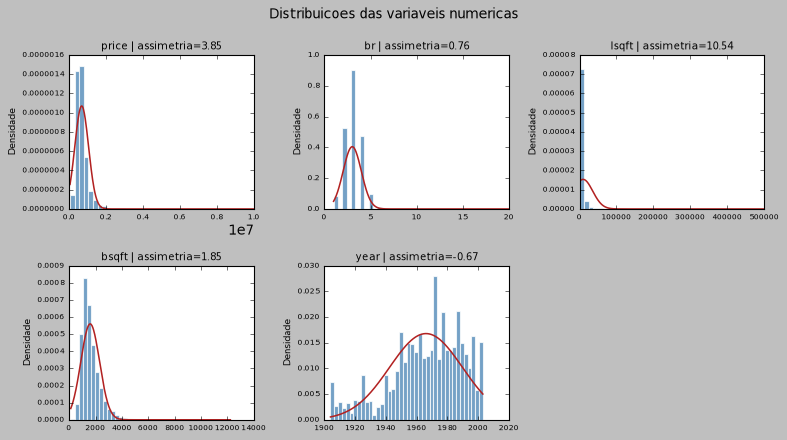

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(10, 5.6))
axes = axes.ravel()

for ax, col in zip(axes, num_cols):
    s = df[col].dropna()
    ax.hist(s, bins=40, density=True, color='steelblue',
            edgecolor='white', alpha=0.75)
    if s.std(ddof=0) > 0:
        x = np.linspace(s.min(), s.max(), 400)
        mu, sigma = s.mean(), s.std(ddof=0)
        normal = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)
        ax.plot(x, normal, color='firebrick', linewidth=1.4)
    ax.set_title(f'{col} | assimetria={df[col].skew():.2f}', fontsize=9)
    ax.tick_params(labelsize=7)
    ax.set_ylabel('Densidade', fontsize=8)

axes[-1].axis('off')
fig.suptitle('Distribuicoes das variaveis numericas', fontsize=12)
plt.tight_layout()
plt.show()


**Tipos de distribuição identificados:**

| Variável | Forma           | Evidência              |
|----------|-----------------|------------------------|
| `price`  | Right-skewed    | skew = 3,85            |
| `br`     | Right-skewed leve | skew = 0,76          |
| `lsqft`  | Right-skewed extremo | skew = 10,54      |
| `bsqft`  | Right-skewed    | skew = 1,85            |
| `year`   | Left-skewed leve | skew = -0,67          |


## 7. Outliers

Três formas de identificação: kurtosis, boxplot e gráfico de dispersão.


In [9]:
# (a) Curtose como indicação inicial, conforme o resumo da disciplina
print('Curtose (valor positivo sugere caudas mais pesadas que a normal):')
for col in num_cols:
    k = df[col].kurt()
    indicacao = 'inspecionar extremos' if k > 0 else 'sem indicação por este critério'
    print(f'  {col:<8}: κ={k:>8.2f}  {indicacao}')

Curtose (valor positivo sugere caudas mais pesadas que a normal):
  price   : κ=   34.03  inspecionar extremos
  br      : κ=    4.76  inspecionar extremos
  lsqft   : κ=  137.41  inspecionar extremos
  bsqft   : κ=    6.64  inspecionar extremos
  year    : κ=   -0.08  sem indicação por este critério


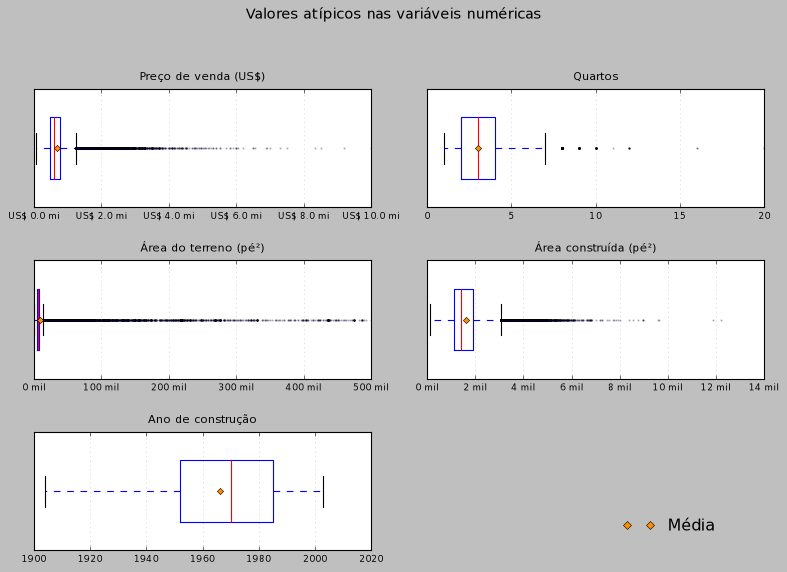

In [10]:
# Boxplots horizontais: os valores extremos ficam legíveis e não se sobrepõem aos títulos.
rotulos = {
    'price': 'Preço de venda (US$)', 'br': 'Quartos',
    'lsqft': 'Área do terreno (pé²)', 'bsqft': 'Área construída (pé²)',
    'year': 'Ano de construção'
}

fig, axes = plt.subplots(3, 2, figsize=(10, 7.4))
axes = axes.ravel()

for ax, col in zip(axes, num_cols):
    valores = df[col].dropna()
    ax.boxplot(valores, showmeans=True, orientation='horizontal', widths=0.52,
               flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.22},
               meanprops={'marker': 'D', 'markersize': 4,
                          'markerfacecolor': 'darkorange', 'markeredgecolor': 'black'})
    ax.set_title(rotulos[col], fontsize=10, pad=8)
    ax.set_yticks([])
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='x', alpha=0.25)
    if col == 'price':
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'US$ {x/1e6:.1f} mi'))
    elif col in ('lsqft', 'bsqft'):
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f} mil'))

axes[-1].axis('off')
fig.suptitle('Valores atípicos nas variáveis numéricas', fontsize=13, y=0.995)
fig.legend(handles=[plt.Line2D([], [], marker='D', linestyle='', markersize=5,
                              markerfacecolor='darkorange', markeredgecolor='black',
                              label='Média')],
           loc='lower right', bbox_to_anchor=(0.92, 0.08), frameon=False)
plt.tight_layout(rect=[0, 0.03, 1, 0.96], h_pad=1.5, w_pad=1.8)
plt.show()


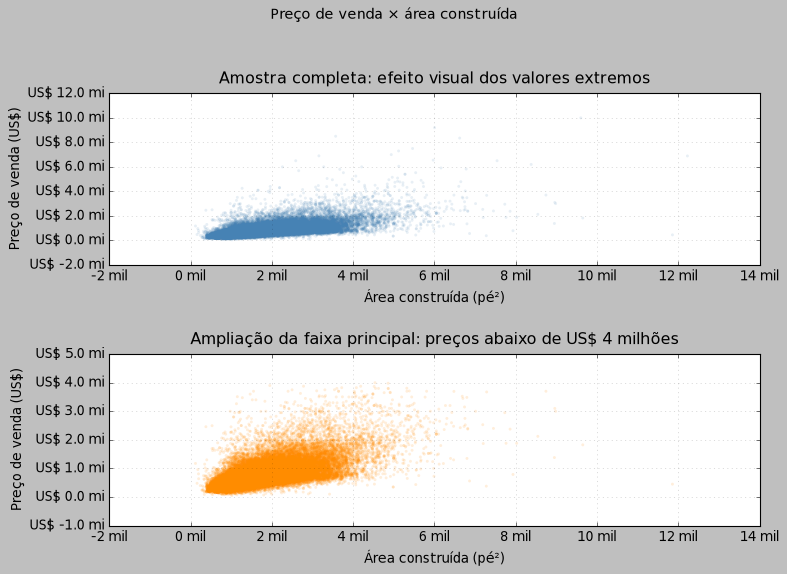

Limite superior pelo critério de 1,5×IQR: US$ 1,256,000
Registros acima desse limite: 6,622
Registros com preço >= US$ 4 milhões: 88


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7.2), sharex=False)

axes[0].scatter(df['bsqft'], df['price'], alpha=0.12, s=7,
                color='steelblue', edgecolors='none')
axes[0].set_title('Amostra completa: efeito visual dos valores extremos', pad=9)
axes[0].set_xlabel('Área construída (pé²)')
axes[0].set_ylabel('Preço de venda (US$)')

limite_visual = 4_000_000
df_sem_cauda = df[df['price'] < limite_visual]
axes[1].scatter(df_sem_cauda['bsqft'], df_sem_cauda['price'], alpha=0.14, s=7,
                color='darkorange', edgecolors='none')
axes[1].set_title('Ampliação da faixa principal: preços abaixo de US$ 4 milhões', pad=9)
axes[1].set_xlabel('Área construída (pé²)')
axes[1].set_ylabel('Preço de venda (US$)')

for ax in axes:
    ax.grid(alpha=0.25)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'US$ {x/1e6:.1f} mi'))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f} mil'))

fig.suptitle('Preço de venda × área construída', fontsize=13, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.96], h_pad=2.0)
plt.show()

q1, q3 = df['price'].quantile([0.25, 0.75])
limite_iqr = q3 + 1.5 * (q3 - q1)
print(f'Limite superior pelo critério de 1,5×IQR: US$ {limite_iqr:,.0f}')
print(f'Registros acima desse limite: {(df["price"] > limite_iqr).sum():,}')
print(f'Registros com preço >= US$ 4 milhões: {(df["price"] >= limite_visual).sum():,}')


**Interpretação dos valores atípicos**

- O boxplot e o critério de 1,5 × IQR identificam uma cauda superior extensa em `price`. Isso não significa que todas essas vendas sejam erros: imóveis de alto padrão fazem parte do mercado estudado.
- O corte de US$ 4 milhões foi usado apenas para comparar a visualização com e sem a parte mais extrema da cauda. Uma eventual exclusão na modelagem dependeria do público-alvo do sistema e deveria ser avaliada por análise de sensibilidade.
- Valores extremos de `lsqft`, `bsqft` e `br` merecem conferência no cadastro. Valores pequenos de terreno também podem representar apartamentos ou particularidades do registro, e não erros automáticos.
- A curtose de `year` próxima de zero não substitui a verificação lógica; anos posteriores à data da venda foram tratados na etapa de ruído.

## 8. Estatística Descritiva vs. Gráficos

Os histogramas abaixo mostram a média (linha vermelha) e a mediana (linha verde) sobrepostas para cada variável.


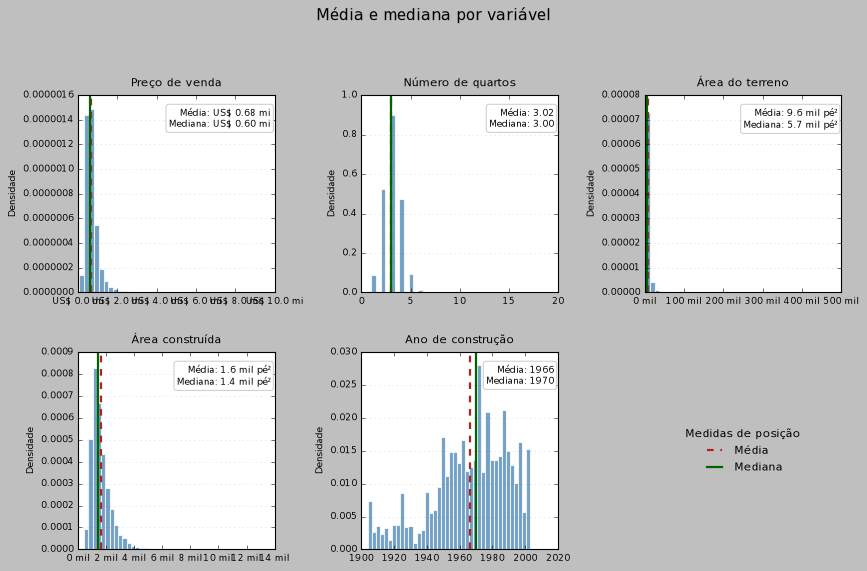

In [12]:
# Painel 2 × 3: cada distribuição ganha espaço para eixos e anotações.
rotulos_distrib = {
    'price': 'Preço de venda', 'br': 'Número de quartos',
    'lsqft': 'Área do terreno', 'bsqft': 'Área construída',
    'year': 'Ano de construção'
}
fig, axes = plt.subplots(2, 3, figsize=(11, 7.2))
axes = axes.ravel()

for ax, col in zip(axes, num_cols):
    s = df[col].dropna()
    s.plot(kind='hist', bins=40, density=True, color='steelblue',
           edgecolor='white', alpha=0.76, ax=ax)
    media, mediana = s.mean(), s.median()
    ax.axvline(media, color='firebrick', lw=2, linestyle='--')
    ax.axvline(mediana, color='darkgreen', lw=2, linestyle='-')
    ax.set_title(rotulos_distrib[col], fontsize=10, pad=8)
    ax.set_ylabel('Densidade', fontsize=8)
    ax.grid(axis='y', alpha=0.2)
    ax.tick_params(labelsize=8)

    if col == 'price':
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'US$ {x/1e6:.1f} mi'))
        formato = lambda v: f'US$ {v/1e6:.2f} mi'
    elif col in ('lsqft', 'bsqft'):
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f} mil'))
        formato = lambda v: f'{v/1000:.1f} mil pé²'
    elif col == 'year':
        ax.ticklabel_format(axis='x', style='plain', useOffset=False)
        formato = lambda v: f'{v:.0f}'
    else:
        formato = lambda v: f'{v:.2f}'

    ax.text(0.98, 0.94, f'Média: {formato(media)}\nMediana: {formato(mediana)}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white',
                  'edgecolor': '#cccccc', 'alpha': 0.9})

axes[-1].axis('off')
legenda = [
    plt.Line2D([], [], color='firebrick', lw=2, linestyle='--', label='Média'),
    plt.Line2D([], [], color='darkgreen', lw=2, linestyle='-', label='Mediana')
]
axes[-1].legend(handles=legenda, loc='center', frameon=False, fontsize=10,
                title='Medidas de posição', title_fontsize=10)
fig.suptitle('Média e mediana por variável', fontsize=14, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=2.0, w_pad=1.7)
plt.show()


Nas variáveis com assimetria à direita (`price`, `lsqft`, `bsqft`, `br`), a média fica deslocada para a direita em relação à mediana — padrão já indicado numericamente na sumarização. Para `year` as duas medidas ficam próximas, coerente com a assimetria leve.

Conforme o fluxograma do Resumo, para distribuições assimétricas a **mediana** é a medida de localização mais adequada, por não ser influenciada pelos extremos da cauda.


## 9. Relacionamento entre Variáveis

Gráficos de dispersão com e sem escala logarítmica para classificar o tipo de relação entre pares de variáveis (Tabela 2 do Resumo).


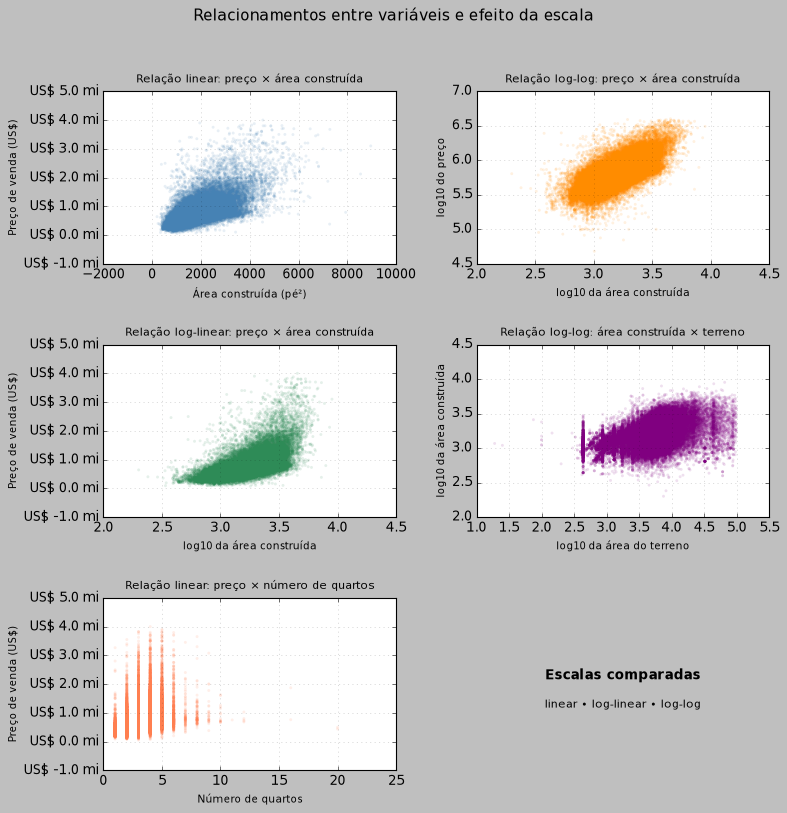

In [13]:
sub = df[['price','bsqft','lsqft','br']].dropna()
sub = sub[(sub['price'] < 4_000_000) & (sub['bsqft'] < 10_000) & (sub['lsqft'] < 100_000)]

fig, axes = plt.subplots(3, 2, figsize=(10, 10.2))
graficos = [
    ('Relação linear: preço × área construída', sub['bsqft'], sub['price'],
     'Área construída (pé²)', 'Preço de venda (US$)', 'steelblue'),
    ('Relação log-log: preço × área construída', np.log10(sub['bsqft']), np.log10(sub['price']),
     'log10 da área construída', 'log10 do preço', 'darkorange'),
    ('Relação log-linear: preço × área construída', np.log10(sub['bsqft']), sub['price'],
     'log10 da área construída', 'Preço de venda (US$)', 'seagreen'),
    ('Relação log-log: área construída × terreno', np.log10(sub['lsqft']), np.log10(sub['bsqft']),
     'log10 da área do terreno', 'log10 da área construída', 'purple'),
    ('Relação linear: preço × número de quartos', sub['br'], sub['price'],
     'Número de quartos', 'Preço de venda (US$)', 'coral'),
]

for ax, (titulo, x, y, xlabel, ylabel, cor) in zip(axes.ravel(), graficos):
    ax.scatter(x, y, alpha=0.12, s=7, color=cor, edgecolors='none')
    ax.set_title(titulo, fontsize=10, pad=8)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(alpha=0.25)
    if ylabel == 'Preço de venda (US$)':
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'US$ {v/1e6:.1f} mi'))

axes[-1, -1].axis('off')
axes[-1, -1].text(0.5, 0.55, 'Escalas comparadas', ha='center', va='center',
                  fontsize=12, fontweight='bold')
axes[-1, -1].text(0.5, 0.38, 'linear • log-linear • log-log', ha='center', va='center', fontsize=10)
fig.suptitle('Relacionamentos entre variáveis e efeito da escala', fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97], h_pad=2.0, w_pad=1.5)
plt.show()


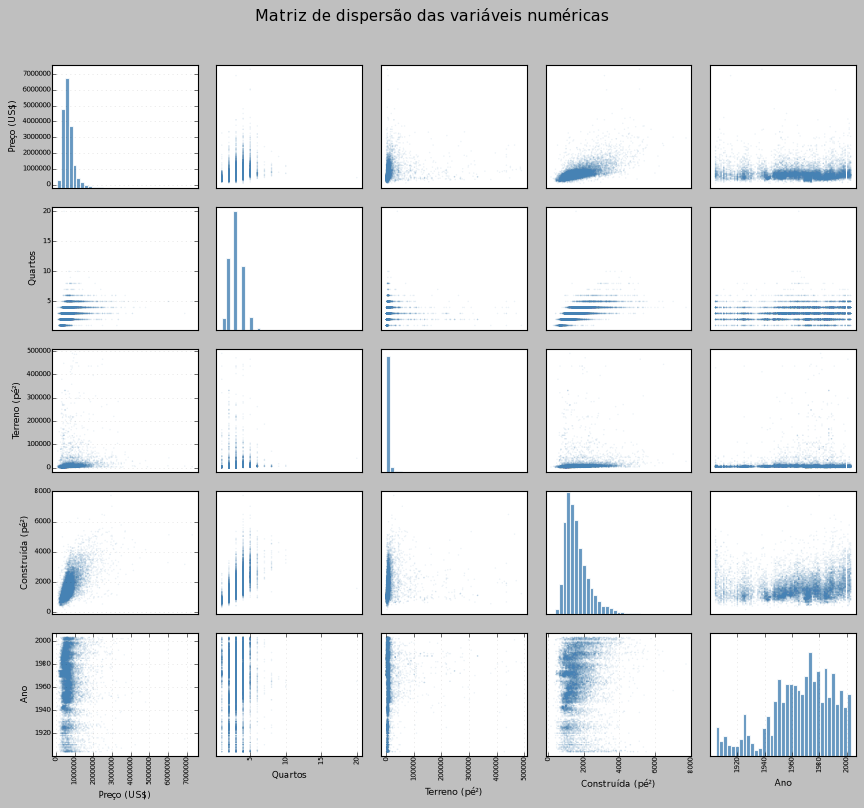

In [14]:
# Amostragem apenas para renderização: preserva os padrões e evita sobreposição excessiva.
from matplotlib.ticker import ScalarFormatter

nomes_matriz = {
    'price': 'Preço (US$)', 'br': 'Quartos', 'lsqft': 'Terreno (pé²)',
    'bsqft': 'Construída (pé²)', 'year': 'Ano'
}
matriz_df = df[num_cols].rename(columns=nomes_matriz)
if len(matriz_df) > 20_000:
    matriz_df = matriz_df.sample(20_000, random_state=42)

mat_axes = scatter_matrix(
    matriz_df, figsize=(11, 10), range_padding=0.08, diagonal='hist',
    color='steelblue', alpha=0.10, s=7,
    hist_kwds={'bins': 35, 'color': 'steelblue', 'alpha': 0.82, 'edgecolor': 'white'}
)
for ax in np.asarray(mat_axes).ravel():
    ax.tick_params(axis='both', labelsize=6, pad=1)
    ax.xaxis.label.set_rotation(0)
    ax.yaxis.label.set_rotation(90)
    ax.xaxis.label.set_size(8)
    ax.yaxis.label.set_size(8)
    ax.grid(alpha=0.15)
    # Exibe anos completos (por exemplo, 2000) em vez do deslocamento "+2e3".
    if ax.get_xlabel() == 'Ano':
        fmt_x = ScalarFormatter(useOffset=False)
        fmt_x.set_scientific(False)
        ax.xaxis.set_major_formatter(fmt_x)
    if ax.get_ylabel() == 'Ano':
        fmt_y = ScalarFormatter(useOffset=False)
        fmt_y.set_scientific(False)
        ax.yaxis.set_major_formatter(fmt_y)

plt.suptitle('Matriz de dispersão das variáveis numéricas', fontsize=14, y=1.01)
plt.tight_layout(pad=1.2)
plt.show()


**Leitura dos gráficos com base na Tabela 2 do resumo:**

| Par | Escala em que o padrão ficou mais próximo de uma reta | Classificação exploratória |
|---|---|---|
| `price` × `bsqft` | log(`price`) × log(`bsqft`) | Log-Log |
| `lsqft` × `bsqft` | log(`lsqft`) × log(`bsqft`) | Log-Log |
| `price` × `br` | escala original | Aproximadamente linear, com grande dispersão |
| `price` × `year` | escala original | Sem relação evidente |

Essa classificação é visual e serve como hipótese para a modelagem. Ela não demonstra, sozinha, que uma transformação ou um modelo específico será superior; isso deve ser confirmado por diagnóstico e validação do modelo.

## 10. Correlações

Coeficientes de Pearson e Spearman. Conforme a Seção 3.7 do Resumo, Pearson é adequado para relações lineares; Spearman para relações não-lineares.


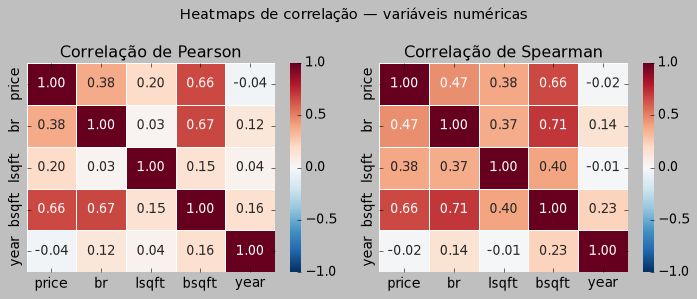

In [15]:
corr_p = df[num_cols].corr('pearson')
corr_s = df[num_cols].corr('spearman')

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))

sns.heatmap(corr_p, cmap='RdBu_r', vmin=-1, vmax=1, annot=True, fmt='.2f',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Correlação de Pearson')

sns.heatmap(corr_s, cmap='RdBu_r', vmin=-1, vmax=1, annot=True, fmt='.2f',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Correlação de Spearman')

plt.suptitle('Heatmaps de correlação — variáveis numéricas', fontsize=13)
plt.tight_layout()
plt.show()


- `bsqft` × `price`: Spearman = 0,66, correlação moderada segundo os limites do resumo.
- `br` × `price`: Spearman = 0,47, correlação fraca.
- `lsqft` × `price`: Spearman = 0,38, correlação fraca.
- `year` × `price`: Spearman = -0,02, sem associação monotônica relevante no recorte.

Pearson descreve associação linear, enquanto Spearman descreve associação monotônica por postos. Nos pares cuja inspeção visual sugeriu curvatura, Spearman foi usado como complemento. A diferença mais visível ocorre em `lsqft` × `price` (0,38 em Spearman e 0,20 em Pearson). Correlação não implica causalidade e pode ser afetada por localização e outras variáveis omitidas.

## 11. Multicolinearidade

Identificação de pares com correlação forte (|ρ| > 0,75) entre variáveis independentes. Pares fortemente correlacionados precisam de tratamento para evitar multicolinearidade.


In [16]:
print('Pares de variáveis explicativas com |correlação| > 0,75:')
print()

ind_cols = ['br', 'lsqft', 'bsqft', 'year']
found = False

for metodo, corr in [('Pearson', corr_p), ('Spearman', corr_s)]:
    print(f'--- {metodo} ---')
    for i in range(len(ind_cols)):
        for j in range(i + 1, len(ind_cols)):
            r = corr.loc[ind_cols[i], ind_cols[j]]
            classe = 'forte' if abs(r) > 0.75 else 'fraca ou moderada'
            print(f'  {ind_cols[i]:<8} x {ind_cols[j]:<8}: r={r:+.2f}  {classe}')
            found = found or abs(r) > 0.75
    print()

if not found:
    print('Nenhum par numérico ultrapassou o limite de 0,75 adotado no resumo.')

Pares de variáveis explicativas com |correlação| > 0,75:

--- Pearson ---
  br       x lsqft   : r=+0.03  fraca ou moderada
  br       x bsqft   : r=+0.67  fraca ou moderada
  br       x year    : r=+0.12  fraca ou moderada
  lsqft    x bsqft   : r=+0.15  fraca ou moderada
  lsqft    x year    : r=+0.04  fraca ou moderada
  bsqft    x year    : r=+0.16  fraca ou moderada

--- Spearman ---
  br       x lsqft   : r=+0.37  fraca ou moderada
  br       x bsqft   : r=+0.71  fraca ou moderada
  br       x year    : r=+0.14  fraca ou moderada
  lsqft    x bsqft   : r=+0.40  fraca ou moderada
  lsqft    x year    : r=-0.01  fraca ou moderada
  bsqft    x year    : r=+0.23  fraca ou moderada

Nenhum par numérico ultrapassou o limite de 0,75 adotado no resumo.


Nenhum par das variáveis numéricas explicativas ultrapassa |r| = 0,75 em Pearson ou Spearman. Portanto, **não foi encontrada correlação par a par forte por esse critério**. Isso não prova ausência completa de multicolinearidade: a confirmação, na etapa de modelagem, pode incluir VIF e análise conjunta das variáveis codificadas.

A correlação entre `bsqft` e `price` não é motivo para remover `bsqft`, pois envolve uma variável explicativa e o alvo. A verificação desta seção não inclui `city`, `county` e `zip`, que são categóricas e exigem outras formas de codificação e associação.

## 12. Transformações Promissoras

Para variáveis right-skewed, o Resumo recomenda transformação **logarítmica (base 10)**. Abaixo, comparação da distribuição original e da transformada para as três variáveis afetadas.


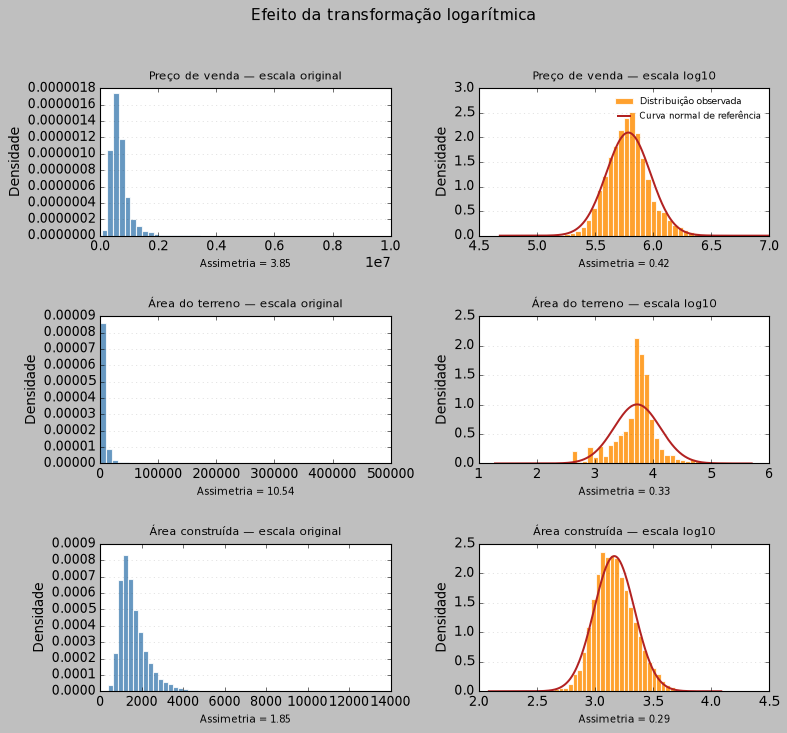

In [17]:
transf_cols = ['price', 'lsqft', 'bsqft']  # br e year ficam sem transformação
rotulos_transf = {
    'price': 'Preço de venda', 'lsqft': 'Área do terreno',
    'bsqft': 'Área construída'
}

# Três linhas (àrea, terreno, preço) × duas colunas (original, log10).
fig, axes = plt.subplots(len(transf_cols), 2, figsize=(10, 9.2))

for i, col in enumerate(transf_cols):
    s = df[col].dropna()
    s_log = np.log10(s[s > 0])

    axes[i, 0].hist(s, bins=50, density=True, color='steelblue',
                    edgecolor='white', alpha=0.82)
    axes[i, 0].set_title(f'{rotulos_transf[col]} — escala original', fontsize=10, pad=8)
    axes[i, 0].set_xlabel(f'Assimetria = {s.skew():.2f}', fontsize=9)

    axes[i, 1].hist(s_log, bins=50, density=True, color='darkorange',
                    edgecolor='white', alpha=0.82, label='Distribuição observada')
    mu, sigma = s_log.mean(), s_log.std(ddof=0)
    x = np.linspace(s_log.min(), s_log.max(), 300)
    axes[i, 1].plot(x, (1/(sigma*np.sqrt(2*np.pi)))*np.exp(-0.5*((x-mu)/sigma)**2),
                    color='firebrick', lw=1.8, label='Curva normal de referência')
    axes[i, 1].set_title(f'{rotulos_transf[col]} — escala log10', fontsize=10, pad=8)
    axes[i, 1].set_xlabel(f'Assimetria = {s_log.skew():.2f}', fontsize=9)

    for ax in axes[i]:
        ax.set_ylabel('Densidade')
        ax.grid(axis='y', alpha=0.2)

axes[0, 1].legend(loc='upper right', fontsize=8, frameon=False)
fig.suptitle('Efeito da transformação logarítmica', fontsize=14, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97], h_pad=2.0, w_pad=1.5)
plt.show()


**Transformações promissoras com base na Tabela 3 do resumo:**

| Variável | Forma observada | Alternativa | Assimetria após a transformação |
|---|---|---|---:|
| `price` | Assimetria à direita | log10 | 0,42 |
| `lsqft` | Assimetria acentuada à direita | log10 | 0,33 |
| `bsqft` | Assimetria à direita | log10 | 0,29 |
| `br` | Assimetria leve à direita | manter inicialmente | 0,76 |
| `year` | Assimetria à esquerda | manter inicialmente | -0,67 |

A transformação log10 reduziu a assimetria das três variáveis e, por isso, é uma alternativa promissora para experimentos posteriores. Em regressão linear, a hipótese de normalidade se refere principalmente aos resíduos condicionais, não à variável-alvo isoladamente. Assim, a decisão de transformar `price` deve ser confirmada pelos diagnósticos do modelo e pela interpretação desejada dos coeficientes.

## 13. Dados Adicionais Úteis

Informações que poderiam melhorar a capacidade preditiva do modelo:

1. **Avaliação de escolas por bairro** — qualidade das escolas públicas tem impacto direto nos preços em São Francisco.
2. **Distância ao centro financeiro** — proximidade a hubs de emprego é um dos principais drivers de preço.
3. **Estado de conservação do imóvel** — ausente no dataset; explica boa parte da variação dentro de um mesmo CEP.
4. **Número de banheiros e vagas de garagem** — features padrão em modelos de precificação imobiliária.
5. **Índice de crime por bairro** — influencia diretamente a valorização em grandes metrópoles americanas.


## 14. Síntese da análise

**Qualidade dos dados:**  
O recorte contém 113.991 vendas de 2005 e 113.745 registros após a aplicação dos critérios operacionais de plausibilidade. Há ausência relevante em `br`, `lsqft`, `bsqft` e `year`, além de duas duplicidades segundo a chave declarada no enunciado. Essas duplicidades não foram eliminadas automaticamente porque não são cópias completas.

**Distribuições:**  
`price`, `lsqft` e `bsqft` apresentam assimetria à direita. A transformação logarítmica reduz essa assimetria, mas sua adoção deve ser confirmada na etapa de modelagem. `year` apresenta assimetria negativa moderada.

**Valores atípicos:**  
Os gráficos mostram caudas e observações extremas, especialmente em preço e áreas. Parte delas pode representar imóveis reais de alto padrão. Por isso, o corte de US$ 4 milhões foi usado somente como comparação visual, e não como exclusão definitiva.

**Relacionamentos:**  
`bsqft` apresenta a maior associação com `price` entre as variáveis numéricas avaliadas (Spearman = 0,66). `year` praticamente não apresenta associação monotônica com o preço neste recorte. Localização e possíveis variáveis omitidas devem ser consideradas antes de interpretar essas relações.

**Correlação entre explicativas:**  
Nenhum par numérico ultrapassou |r| = 0,75. Esse resultado não indica correlação par a par forte pelo critério do resumo, mas não substitui diagnósticos de multicolinearidade durante a modelagem.

**Próximos passos:**  
Comparar modelos com e sem transformação logarítmica, codificar as variáveis de localização e avaliar o efeito das decisões sobre ausentes e extremos por validação fora da amostra.

## Referências

1. LAU, Sam; GONZALEZ, Joey; NOLAN, Deb. *Learning Data Science*. Sebastopol: O’Reilly Media, 2023. Base `sfhousing.csv` e exemplo “Sale Prices for Houses”. Disponível em: <https://learningds.org/ch/10/eda_example.html>. Acesso em: 24 jul. 2026.

2. LAU, Sam; GONZALEZ, Joey; NOLAN, Deb. *SF Bay Area Housing (`sfhousing.csv`)*. Repositório do livro *Learning Data Science*. Dados originalmente coletados das páginas imobiliárias do *San Francisco Chronicle*. Disponível em: <https://github.com/DS-100/textbook/tree/master/content/datasets>. Acesso em: 24 jul. 2026.

3. SOUSA, Alexandre Magno de. *Resumo — Estatística Descritiva e Visualização de Dados*. Material da disciplina CDD105, Universidade Federal de Ouro Preto, 2026.

4. HARRIS, Charles R. et al. Array programming with NumPy. *Nature*, v. 585, p. 357–362, 2020. DOI: <https://doi.org/10.1038/s41586-020-2649-2>.

5. McKINNEY, Wes. Data structures for statistical computing in Python. In: *Proceedings of the 9th Python in Science Conference*, p. 56–61, 2010. DOI: <https://doi.org/10.25080/Majora-92bf1922-00a>.

6. HUNTER, John D. Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, v. 9, n. 3, p. 90–95, 2007. DOI: <https://doi.org/10.1109/MCSE.2007.55>.

7. WASKOM, Michael L. seaborn: statistical data visualization. *Journal of Open Source Software*, v. 6, n. 60, 2021. DOI: <https://doi.org/10.21105/joss.03021>.


---
## Exercício Extra — Mapa de Imóveis por CEP

Os CEPs presentes nos dados de 2005 são convertidos em coordenadas geográficas e representados em duas camadas: **mapa de calor do volume de vendas** e **preço mediano por CEP**. No PDF, as duas camadas são apresentadas lado a lado; na versão HTML, o controle no canto superior direito permite ativar ou ocultar cada camada.

O arquivo `mapa_imoveis_2005.html` preserva todos os recursos interativos, incluindo seleção de camadas, zoom, deslocamento, dicas e detalhes por CEP.


In [18]:
# Passo 1: CEPs únicos com estatísticas de preço
df['zip_str'] = df['zip'].dropna().astype(int).astype(str).str.zfill(5)

zip_stats = df.groupby('zip_str').agg(
    vendas        = ('price', 'count'),
    preco_mediano = ('price', 'median'),
    preco_medio   = ('price', 'mean')
).reset_index()

print(f'CEPs únicos: {len(zip_stats)}')
print(f'Registros sem CEP: {df["zip"].isna().sum()}')
zip_stats.sort_values('vendas', ascending=False).head(10)

CEPs únicos: 288
Registros sem CEP: 7


,zip_str,vendas,preco_mediano,preco_medio
78,94513,2266,620000.00,630077.01
118,94565,2014,435000.00,462753.23
92,94533,1734,420000.00,440777.10
75,94509,1587,430000.00,440081.31
138,94591,1380,509000.00,523181.88
234,95123,1353,585000.00,551948.63
284,95687,1338,431000.00,460341.18
130,94582,1325,948000.00,956532.08
121,94568,1287,615000.00,737649.57
91,94531,1233,552000.00,570820.36


In [19]:
import ssl, urllib.request, zipfile, io, os

GEO_FILE = 'us_zip_coords.csv'

if not os.path.exists(GEO_FILE):
    print('Baixando base GeoNames US ZIP codes...')
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    with urllib.request.urlopen('https://download.geonames.org/export/zip/US.zip',
                                context=ctx) as resp:
        raw = resp.read()
    with zipfile.ZipFile(io.BytesIO(raw)) as z:
        with z.open('US.txt') as f:
            geo_base = pd.read_csv(
                f, sep='\t', header=None,
                names=['country','zip','place','state','state_code',
                       'county','county_code','community','community_code',
                       'lat','lon','accuracy']
            )
    geo_base.to_csv(GEO_FILE, index=False)
    print(f'Base salva: {len(geo_base):,} registros')
else:
    geo_base = pd.read_csv(GEO_FILE, dtype={'zip': str})
    print(f'Base GeoNames carregada do cache: {len(geo_base):,} registros')

geo_base['zip'] = geo_base['zip'].astype(str).str.zfill(5)
geo_lookup = geo_base[['zip','place','state_code','lat','lon']].drop_duplicates('zip')

zip_geo = zip_stats.merge(geo_lookup, left_on='zip_str', right_on='zip', how='left')
zip_geo_ok = zip_geo.dropna(subset=['lat','lon']).copy()

print(f'\nCEPs geocodificados: {len(zip_geo_ok)} / {len(zip_stats)}')
zip_geo_ok[['zip_str','place','state_code','lat','lon','vendas','preco_mediano']].head(5)

Base GeoNames carregada do cache: 41,490 registros

CEPs geocodificados: 287 / 288


,zip_str,place,state_code,lat,lon,vendas,preco_mediano
0,94002,Belmont,CA,37.52,-122.29,350,860000.00
1,94005,Brisbane,CA,37.68,-122.40,95,650000.00
2,94010,Burlingame,CA,37.57,-122.37,490,1350000.00
3,94014,Daly City,CA,37.69,-122.44,422,669500.00
4,94015,Daly City,CA,37.68,-122.48,608,683500.00


In [20]:
# Passo 3: exportar CSV para GPSVisualizer
gpsvis = zip_geo_ok.copy()
gpsvis['name'] = gpsvis['zip_str']
gpsvis['desc'] = gpsvis.apply(
    lambda r: f"{r['place']}, {r['state_code']} | {int(r['vendas'])} vendas | mediana ${r['preco_mediano']:,.0f}",
    axis=1
)
gpsvis[['name','desc','lat','lon']].rename(
    columns={'lat':'latitude','lon':'longitude'}
).to_csv('zips_para_gpsvisualizer.csv', index=False)

print('Arquivo "zips_para_gpsvisualizer.csv" gerado —', len(gpsvis), 'pontos')
print('Carregar em: https://www.gpsvisualizer.com/convert_input')

Arquivo "zips_para_gpsvisualizer.csv" gerado — 287 pontos
Carregar em: https://www.gpsvisualizer.com/convert_input


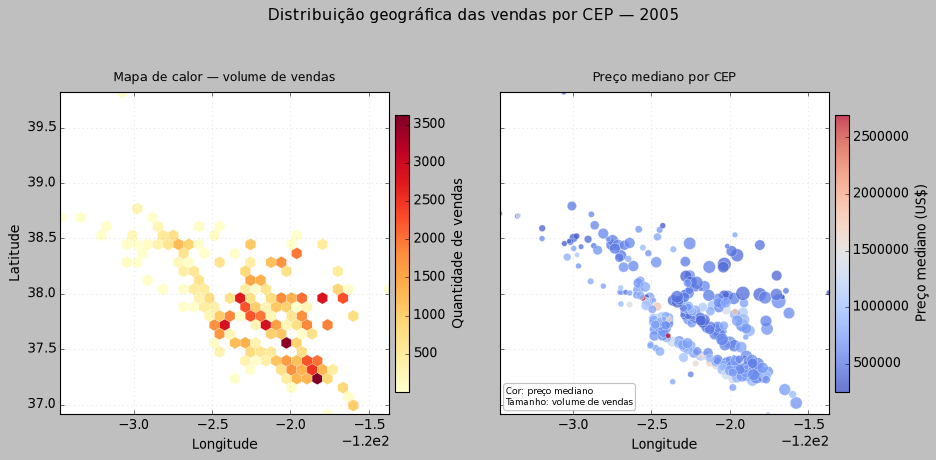

Mapa interativo salvo: mapa_imoveis_2005.html


In [21]:
import folium
from folium.plugins import HeatMap
from IPython.display import display

# Versão estática para o PDF: apresenta simultaneamente as duas camadas
# que podem ser selecionadas no mapa interativo.
fig, axes = plt.subplots(1, 2, figsize=(12, 5.8), sharex=True, sharey=True)

heat = axes[0].hexbin(
    zip_geo_ok['lon'], zip_geo_ok['lat'], C=zip_geo_ok['vendas'],
    reduce_C_function=np.sum, gridsize=32, mincnt=1, cmap='YlOrRd',
    linewidths=0.15, edgecolors='white'
)
cbar_heat = fig.colorbar(heat, ax=axes[0], pad=0.015, shrink=0.86)
cbar_heat.set_label('Quantidade de vendas')
axes[0].set_title('Mapa de calor — volume de vendas', fontsize=11, pad=10)

sizes = 18 + 150 * np.sqrt(zip_geo_ok['vendas'] / zip_geo_ok['vendas'].max())
points = axes[1].scatter(
    zip_geo_ok['lon'], zip_geo_ok['lat'], c=zip_geo_ok['preco_mediano'],
    s=sizes, cmap='coolwarm', alpha=0.76, edgecolor='white', linewidth=0.35
)
cbar_price = fig.colorbar(points, ax=axes[1], pad=0.015, shrink=0.86)
cbar_price.set_label('Preço mediano (US$)')
axes[1].set_title('Preço mediano por CEP', fontsize=11, pad=10)
axes[1].text(
    0.02, 0.02, 'Cor: preço mediano\nTamanho: volume de vendas',
    transform=axes[1].transAxes, fontsize=8, va='bottom',
    bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white',
          'edgecolor': '#bbbbbb', 'alpha': 0.9}
)

for ax in axes:
    ax.set_xlabel('Longitude')
    ax.grid(alpha=0.18)
axes[0].set_ylabel('Latitude')
fig.suptitle('Distribuição geográfica das vendas por CEP — 2005', fontsize=14, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.95], w_pad=1.8)
plt.show()

# Versão interativa preservada no notebook/HTML e salva como arquivo independente.
center = [zip_geo_ok['lat'].mean(), zip_geo_ok['lon'].mean()]
m = folium.Map(location=center, zoom_start=9, tiles='CartoDB positron')
heat_group = folium.FeatureGroup(name='Mapa de calor — volume de vendas', show=True)
HeatMap([[r['lat'], r['lon'], r['vendas']] for _, r in zip_geo_ok.iterrows()],
        min_opacity=0.3, radius=18, blur=12).add_to(heat_group)
heat_group.add_to(m)

price_min = zip_geo_ok['preco_mediano'].min()
price_max = zip_geo_ok['preco_mediano'].max()
fg = folium.FeatureGroup(name='Preço mediano por CEP', show=True)
for _, row in zip_geo_ok.iterrows():
    t = (row['preco_mediano'] - price_min) / (price_max - price_min)
    color = f'hsl({int((1-t)*240)}, 80%, 45%)'
    radius = 4 + (row['vendas'] / zip_geo_ok['vendas'].max()) * 14
    popup = (f"<b>CEP {row['zip_str']}</b><br>{row['place']}, {row['state_code']}<br>"
             f"Vendas em 2005: <b>{int(row['vendas'])}</b><br>"
             f"Preço mediano: <b>US$ {row['preco_mediano']:,.0f}</b>")
    folium.CircleMarker(location=[row['lat'], row['lon']], radius=radius,
                        color=color, fill=True, fill_color=color, fill_opacity=0.7,
                        popup=folium.Popup(popup, max_width=240),
                        tooltip=f"CEP {row['zip_str']} | US$ {row['preco_mediano']:,.0f}").add_to(fg)
fg.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)
m.get_root().html.add_child(folium.Element("""
<div style="position:fixed;bottom:28px;left:28px;z-index:1000;
            background:white;padding:11px 13px;border-radius:7px;
            border:1px solid #999;box-shadow:0 1px 5px rgba(0,0,0,.25);
            font-size:12px;line-height:1.55">
  <b>Legenda — preço mediano por CEP</b><br>
  <span style="color:hsl(240,80%,45%);font-size:17px">&#9679;</span> Menor preço<br>
  <span style="color:hsl(120,80%,45%);font-size:17px">&#9679;</span> Preço intermediário<br>
  <span style="color:hsl(0,80%,45%);font-size:17px">&#9679;</span> Maior preço<br>
  <span style="color:#555">Tamanho do círculo = volume de vendas</span><br>
  <i>Use o controle no canto superior direito<br>para ativar ou ocultar as camadas.</i>
</div>
"""))
m.save('mapa_imoveis_2005.html')
print('Mapa interativo salvo: mapa_imoveis_2005.html')
display(m)
